# Download and mask ERA5 precipitation data for Africa

This notebook downloads monthly ERA5 precipitation data from the Copernicus Climate Data Store using `cdsapi`, extracts the NetCDF file, applies a precise Africa mask using `c3s_atlas.mask_africa`, previews the result, and saves the final masked NetCDF.

Before running it, make sure your CDS credentials are configured in `~/.cdsapirc`.

In [1]:
from importlib import reload
from pathlib import Path

import cdsapi
import matplotlib.pyplot as plt
import xarray as xr
import geopandas as gpd
import regionmask
from shapely.ops import unary_union

import c3s_atlas.customized_regions as cr


/home/abdessamadelh/miniconda3/envs/atlas-env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Resolve project paths

This makes the notebook work whether Jupyter was started from the repository root or from a subdirectory.

In [2]:
repo_root = next(
    path for path in [Path.cwd(), *Path.cwd().parents]
    if (path / "c3s_atlas").exists() and (path / "auxiliar").exists()
)

dest = repo_root / "book" / "customizing" / "data" / "africa_era5_precip"
dest.mkdir(parents=True, exist_ok=True)

repo_root, dest


(PosixPath('/home/abdessamadelh/Documents/stage/Tests/c3s-atlas-main'),
 PosixPath('/home/abdessamadelh/Documents/stage/Tests/c3s-atlas-main/book/customizing/data/africa_era5_precip'))

## Download ERA5 from CDS

This version uses the official CDS ERA5 monthly means product instead of the atlas-ready precipitation field. It downloads `total_precipitation`, then converts it from metres to millimetres and renames it to `r` for consistency with the rest of the workflow.

In [3]:
c = cdsapi.Client()

nc_path = dest / "tp_ERA5_Africa_monthly.nc"
dataset = "reanalysis-era5-single-levels-monthly-means"
request = {
    "product_type": "monthly_averaged_reanalysis",
    "variable": "total_precipitation",
    "year": [str(year) for year in range(1940, 2025)],
    "month": [f"{month:02d}" for month in range(1, 13)],
    "time": "00:00",
    "format": "netcdf",
    "area": [38, -20, -36, 55],
}

if not nc_path.exists():
    c.retrieve(dataset, request, str(nc_path))
    print("Download complete.")
else:
    print(f"NetCDF already present: {nc_path}")


NetCDF already present: /home/abdessamadelh/Documents/stage/Tests/c3s-atlas-main/book/customizing/data/africa_era5_precip/tp_ERA5_Africa_monthly.nc


## Open the downloaded NetCDF

In [4]:
nc_path = dest / "tp_ERA5_Africa_monthly.nc"
if not nc_path.exists():
    raise FileNotFoundError(f"Expected NetCDF file not found: {nc_path}")

ds = xr.open_dataset(nc_path)

rename_map = {}
if "latitude" in ds.coords:
    rename_map["latitude"] = "lat"
if "longitude" in ds.coords:
    rename_map["longitude"] = "lon"
if rename_map:
    ds = ds.rename(rename_map)

# Merge possible ERA5 expver slices into one field.
for name in list(ds.data_vars):
    if "expver" in ds[name].dims:
        ds[name] = ds[name].max("expver", skipna=True)

if "tp" in ds.data_vars:
    ds["r"] = ds["tp"] * 1000.0
    ds["r"].attrs.update({
        "standard_name": "lwe_thickness_of_precipitation_amount",
        "units": "mm",
        "long_name": "Monthly total precipitation",
        "comment": "Converted from ERA5 total_precipitation monthly means in metres to millimetres.",
    })
    ds = ds.drop_vars("tp")

if "r" in ds.data_vars:
    ds.attrs["variable_id"] = "r"

print("Opened:", nc_path.name)
print("Dimensions:", ds.dims)
print("Data variables:", list(ds.data_vars))
ds


Opened: tp_ERA5_Africa_monthly.nc
Dimensions: FrozenMappingWarningOnValuesAccess({'valid_time': 1020, 'lat': 297, 'lon': 301})
Data variables: ['r']


<xarray.Dataset> Size: 365MB
Dimensions:     (valid_time: 1020, lat: 297, lon: 301)
Coordinates:
    number      int64 8B ...
  * valid_time  (valid_time) datetime64[ns] 8kB 1940-01-01T06:00:00 ... 2024-...
  * lat         (lat) float64 2kB 38.0 37.75 37.5 37.25 ... -35.5 -35.75 -36.0
  * lon         (lon) float64 2kB -20.0 -19.75 -19.5 -19.25 ... 54.5 54.75 55.0
    expver      (valid_time) <U4 16kB ...
Data variables:
    r           (valid_time, lat, lon) float32 365MB 4.536 4.339 ... 3.721 3.841
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-04-06T09:37 GRIB to CDM+CF via cfgrib-0.9.1...
    variable_id:             r

## Build a precise Africa mask from a finer Natural Earth layer and apply it

This avoids the incomplete local Africa GeoJSON and uses a finer-resolution Natural Earth country boundary layer directly.

In [5]:
reload(cr)

world = gpd.read_file(
    "https://naturalearth.s3.amazonaws.com/50m_cultural/ne_50m_admin_0_countries.zip"
)
africa_gdf = world[world["CONTINENT"] == "Africa"].copy()

# Fix possible geometry issues before dissolving into one continent polygon.
africa_gdf["geometry"] = africa_gdf.geometry.buffer(0)
africa_shape = unary_union(africa_gdf.geometry)

africa_region = regionmask.Regions(
    [africa_shape],
    names=["Africa"],
    abbrevs=["AFR"],
    name="Africa continent",
)

mask = africa_region.mask(ds["lon"], ds["lat"])
ds_africa = ds.where(mask == 0)
ds_africa = cr.crop_to_bbox(ds_africa, lon_bounds=(-18.0, 52.0), lat_bounds=(-35.0, 37.5))

print("African entities used:", len(africa_gdf))
print("Sample names:", africa_gdf["NAME"].head().tolist())
print("Masked dimensions:", ds_africa.dims)
print("Masked variables:", list(ds_africa.data_vars))
ds_africa


African entities used: 54
Sample names: ['Zimbabwe', 'Zambia', 'Uganda', 'Tunisia', 'Togo']
Masked dimensions: FrozenMappingWarningOnValuesAccess({'valid_time': 1020, 'lat': 291, 'lon': 281})
Masked variables: ['r']


<xarray.Dataset> Size: 334MB
Dimensions:     (valid_time: 1020, lat: 291, lon: 281)
Coordinates:
    number      int64 8B 0
  * valid_time  (valid_time) datetime64[ns] 8kB 1940-01-01T06:00:00 ... 2024-...
  * lat         (lat) float64 2kB 37.5 37.25 37.0 36.75 ... -34.5 -34.75 -35.0
  * lon         (lon) float64 2kB -18.0 -17.75 -17.5 -17.25 ... 51.5 51.75 52.0
    expver      (valid_time) <U4 16kB ...
Data variables:
    r           (valid_time, lat, lon) float32 334MB nan nan nan ... nan nan nan
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-04-06T09:37 GRIB to CDM+CF via cfgrib-0.9.1...
    variable_id:             r

## Quick preview

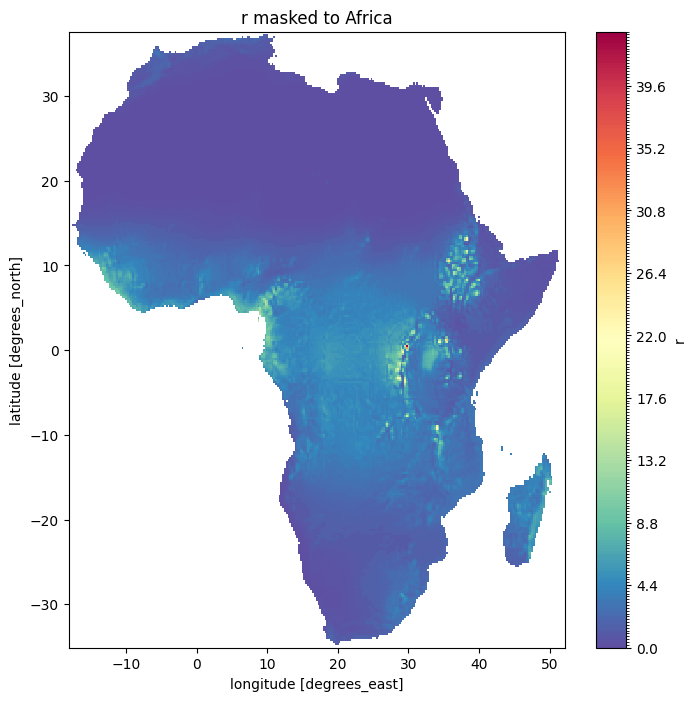

In [6]:
preferred_vars = ["r", "pr", "tp", "precip", "monthly_precipitation"]
var_name = next((name for name in preferred_vars if name in ds_africa.data_vars), None)

if var_name is None:
    candidates = [
        name for name, da in ds_africa.data_vars.items()
        if {"lat", "lon"}.issubset(da.dims) and "bnds" not in da.dims
    ]
    if not candidates:
        raise ValueError("No plottable data variable with lat/lon dimensions was found.")
    var_name = candidates[0]

da = ds_africa[var_name]
time_dims = [dim for dim in ("time", "valid_time") if dim in da.dims]
plot_da = da.mean(time_dims[0], skipna=True) if time_dims else da

#plot_da.plot(figsize=(8, 8), cmap="coolwarm", vmin=10, vmax=35)
plot_da.plot(figsize=(8, 8), cmap="Spectral_r", levels=255)


plt.title(f"{var_name} masked to Africa")
plt.show()


## Save the final Africa-only NetCDF

This drops auxiliary bounds variables before writing to keep the output cleaner and lighter.

In [7]:
bounds_vars = [name for name in ds_africa.variables if "bnds" in name.lower() or name.lower().endswith("_bounds")]
ds_africa_clean = ds_africa.drop_vars(bounds_vars, errors="ignore")
output_path = dest / "era5_africa_precip_masked.nc"

if output_path.exists():
    output_path.unlink()

ds.close()
 
output_path = dest / "era5_africa_precip_masked.nc"
encoding = {
    name: {"zlib": True, "complevel": 1}
    for name in ds_africa_clean.data_vars
}

ds_africa_clean.to_netcdf(output_path, encoding=encoding)
print("Saved:", output_path)


Saved: /home/abdessamadelh/Documents/stage/Tests/c3s-atlas-main/book/customizing/data/africa_era5_precip/era5_africa_precip_masked.nc
